## IsTheWorldReadyForTheNextPandemic - Mini Project
### Project handled by Liza, Ravit, Hagit and Hodaya

**This notebook includes running of Logistic Regression Model as well as running of Random Forest model and comparison between them**



---
## Part 4 · Logistic Regression Model Vs Random Forest Model


*italicized text*K Fold=5 and Repeated=10:
במטריצה הסופית קיבלנו 219 מדינות בסה"כ.

בכל אחד מ-5 הסבבים, המחשב ייקח כ-44 מדינות (20% מהנתונים)
וישמור אותן בצד כסט בחינה (Test), ויתאמן על כ-175 המדינות הנותרות (80%)

המחשב יערבב את 219 המדינות הללו מחדש ויחזור על התהליך 10 פעמים [5 סבבים × 10 חזרות = 50 הרצות סך הכל]



In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# Core imports.
import numpy as np
np.random.seed(42)  # For reproducibility
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set the path where your DataSet CSVs located.
data_dir = '/content/drive/MyDrive/DS_IsTheWorldReadyForTheNextPandemic/DATASET TO USE/'


## Baseline - Logistic Regression:


In [4]:
import os
import pandas as pd
import numpy as np

# ייבוא הרכיבים הנחוצים מתוך Scikit-Learn
from sklearn.model_selection import RepeatedStratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression

# הגדרת נתיב העבודה שלכן (ליזה, רווית, חגית והודיה)
data_dir = '/content/drive/MyDrive/DS_IsTheWorldReadyForTheNextPandemic/DATASET TO USE/'
FILE_NAME = 'master_model_feature_matrix.csv'

print("1. טוען את מטריצת התכונות הסופית עבור מודל הבסיס...")
df_model = pd.read_csv(os.path.join(data_dir, FILE_NAME))

# =====================================================================
# שלב א': הפרדת הנתונים למשתני קלט (X) ומשתנה מטרה (Y)
# =====================================================================
# הסרת מפתח המדינה הטקסטואלי ומשתנה המטרה מה-X
X = df_model.drop(columns=['location_key', 'Y_is_ready'])
y = df_model['Y_is_ready']

print(f"   - מספר המדינות במודל: {X.shape[0]}")
print(f"   - מספר משתני הניבוי (X1 עד X9): {X.shape[1]}")

# =====================================================================
# שלב ב': הגדרת צינור הנתונים (Pipeline) למניעת זליגה
# =====================================================================
# SimpleImputer ישלים את ערכי ה-NaN של X8 ו-X9 על סמך חציון נתוני האימון בלבד בכל סבב
pipeline_lr = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])

# =====================================================================
# שלב ג': הגדרת מתודולוגיית ה-Validation (ה-5-Fold החוזר)
# =====================================================================
# 5 קבוצות, 10 חזרות = 50 הרצות שונות על 219 המדינות שלכן
cv_strategy = RepeatedStratifiedKFold(n_splits=5, n_repeats=10, random_state=42)

# המדדים להערכת מודל הסיווג
scoring_metrics = ['accuracy', 'f1', 'precision', 'recall']

# =====================================================================
# שלב ד': הרצת המודל וחישוב המדדים
# =====================================================================
print("\n2. מריץ רגרסיה לוגיסטית (Logistic Regression) ב-50 סבבים שונים...")
cv_results_lr = cross_validate(pipeline_lr, X, y, cv=cv_strategy, scoring=scoring_metrics)

# =====================================================================
# שלב ה': הדפסת סיכום מדדי הביצוע (ממוצע ± סטיית תקן)
# =====================================================================
print("\n=========================================================")
print("📊 תוצאות מודל הבסיס: רגרסיה לוגיסטית (Baseline) 📊")
print("=========================================================")
print(f"📈 דיוק כללי (Accuracy):  {cv_results_lr['test_accuracy'].mean():.2%} (±{cv_results_lr['test_accuracy'].std():.2%})")
print(f"🎯 ציון F1-Score:         {cv_results_lr['test_f1'].mean():.2%} (±{cv_results_lr['test_f1'].std():.2%})")
print(f"🔍 רגישות (Recall):        {cv_results_lr['test_recall'].mean():.2%} (±{cv_results_lr['test_recall'].std():.2%})")
print(f"📍 דיוק הסיווג (Precision): {cv_results_lr['test_precision'].mean():.2%} (±{cv_results_lr['test_precision'].std():.2%})")
print("=========================================================")


1. טוען את מטריצת התכונות הסופית עבור מודל הבסיס...
   - מספר המדינות במודל: 219
   - מספר משתני הניבוי (X1 עד X9): 9

2. מריץ רגרסיה לוגיסטית (Logistic Regression) ב-50 סבבים שונים...


/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['X8_smoking' 'X9_diabetes']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['X8_smoking' 'X9_diabetes']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['X8_smoking' 'X9_diabetes']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['X8_smoking' 'X9_diabetes']. At least one non-missing value is needed for imputation with strategy='me


📊 תוצאות מודל הבסיס: רגרסיה לוגיסטית (Baseline) 📊
📈 דיוק כללי (Accuracy):  81.36% (±4.80%)
🎯 ציון F1-Score:         81.49% (±5.23%)
🔍 רגישות (Recall):        82.64% (±9.56%)
📍 דיוק הסיווג (Precision): 81.24% (±5.80%)


/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['X8_smoking' 'X9_diabetes']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['X8_smoking' 'X9_diabetes']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['X8_smoking' 'X9_diabetes']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['X8_smoking' 'X9_diabetes']. At least one non-missing value is needed for imputation with strategy='me

## Random Forest Classifier:


In [5]:
import os
import pandas as pd
import numpy as np

# ייבוא הרכיבים הנחוצים מתוך Scikit-Learn
from sklearn.model_selection import RepeatedStratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier

# הגדרת נתיב העבודה שלכן
data_dir = '/content/drive/MyDrive/DS_IsTheWorldReadyForTheNextPandemic/DATASET TO USE/'
FILE_NAME = 'master_model_feature_matrix.csv'

print("1. טוען את מטריצת התכונות עבור המודל המתקדם...")
df_model = pd.read_csv(os.path.join(data_dir, FILE_NAME))

# הפרדת הנתונים ל-X ו-Y
X = df_model.drop(columns=['location_key', 'Y_is_ready'])
y = df_model['Y_is_ready']

# =====================================================================
# הגדרת צינור הנתונים (Pipeline) עבור Random Forest
# =====================================================================
# הגבלנו את עומק העצים (max_depth=4) כדי להתגונן מפני אימון יתר (Overfitting)
pipeline_rf = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('classifier', RandomForestClassifier(
        n_estimators=100,
        max_depth=4,
        min_samples_split=5,
        random_state=42
    ))
])

# שמירה על אותה אסטרטגיית בדיקה בדיוק להשוואה הוגנת
cv_strategy = RepeatedStratifiedKFold(n_splits=5, n_repeats=10, random_state=42)
scoring_metrics = ['accuracy', 'f1', 'precision', 'recall']

# הרצת המודל
print("\n2. מריץ יער אקראי (Random Forest) ב-50 סבבים שונים...")
cv_results_rf = cross_validate(pipeline_rf, X, y, cv=cv_strategy, scoring=scoring_metrics)

# הדפסת התוצאות
print("\n=========================================================")
print("🌲 תוצאות המודל המתקדם: יער אקראי (Random Forest) 🌲")
print("=========================================================")
print(f"📈 דיוק כללי (Accuracy):  {cv_results_rf['test_accuracy'].mean():.2%} (±{cv_results_rf['test_accuracy'].std():.2%})")
print(f"🎯 ציון F1-Score:         {cv_results_rf['test_f1'].mean():.2%} (±{cv_results_rf['test_f1'].std():.2%})")
print(f"🔍 רגישות (Recall):        {cv_results_rf['test_recall'].mean():.2%} (±{cv_results_rf['test_recall'].std():.2%})")
print(f"📍 דיוק הסיווג (Precision): {cv_results_rf['test_precision'].mean():.2%} (±{cv_results_rf['test_precision'].std():.2%})")
print("=========================================================")


1. טוען את מטריצת התכונות עבור המודל המתקדם...

2. מריץ יער אקראי (Random Forest) ב-50 סבבים שונים...


/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['X8_smoking' 'X9_diabetes']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['X8_smoking' 'X9_diabetes']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['X8_smoking' 'X9_diabetes']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['X8_smoking' 'X9_diabetes']. At least one non-missing value is needed for imputation with strategy='me


🌲 תוצאות המודל המתקדם: יער אקראי (Random Forest) 🌲
📈 דיוק כללי (Accuracy):  83.32% (±4.44%)
🎯 ציון F1-Score:         83.07% (±4.79%)
🔍 רגישות (Recall):        82.18% (±8.81%)
📍 דיוק הסיווג (Precision): 84.97% (±6.64%)


## Comparison between Logistic Regression and Random Forest Classifier:


In [12]:
import os
import pandas as pd
import numpy as np

# ייבוא הרכיבים הנחוצים מתוך Scikit-Learn
from sklearn.model_selection import RepeatedStratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# הגדרת נתיב העבודה שלכן (ליזה, רווית, חגית והודיה)
data_dir = '/content/drive/MyDrive/DS_IsTheWorldReadyForTheNextPandemic/DATASET TO USE/'
FILE_NAME = 'master_model_feature_matrix.csv'

print("1. טוען את מטריצת התכונות הסופית...")
df_model = pd.read_csv(os.path.join(data_dir, FILE_NAME))

# הפרדת הנתונים ל-X ו-Y
X = df_model.drop(columns=['location_key', 'Y_is_ready'])
y = df_model['Y_is_ready']

# =====================================================================
# שלב ב': הגדרת ה-Pipelines (הגנה מפני NaN וזליגה באמצעות keep_empty_features)
# =====================================================================
pipeline_lr = Pipeline([
    ('imputer', SimpleImputer(strategy='median', keep_empty_features=True)),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])

pipeline_rf = Pipeline([
    ('imputer', SimpleImputer(strategy='median', keep_empty_features=True)),
    ('classifier', RandomForestClassifier(n_estimators=100, max_depth=4, min_samples_split=5, random_state=42))
])

# שמירה על אותה אסטרטגיית בדיקה קשיחה (5 קבוצות, 10 חזרות = 50 הרצות)
cv_strategy = RepeatedStratifiedKFold(n_splits=5, n_repeats=10, random_state=42)
scoring_metrics = ['accuracy', 'f1', 'precision', 'recall']

# =====================================================================
# שלב ג': הרצת המודלים
# =====================================================================
print("2. מריץ את שני המודלים ב-50 סבבים במקביל...")
cv_results_lr = cross_validate(pipeline_lr, X, y, cv=cv_strategy, scoring=scoring_metrics)
cv_results_rf = cross_validate(pipeline_rf, X, y, cv=cv_strategy, scoring=scoring_metrics)

# =====================================================================
# שלב ד': בניית טבלת השוואה והדפסתה זה לצד זה
# =====================================================================
# יצירת מילון עם נתוני הממוצעים וסטיות התקן
results_data = {
    'Metric / מדד ביצוע': [
        '📈 דיוק כללי (Accuracy)',
        '🎯 ציון F1-Score',
        '🔍 רגישות (Recall)',
        '📍 דיוק הסיווג (Precision)'
    ],
    'Logistic Regression (Baseline)': [
        f"{cv_results_lr['test_accuracy'].mean():.2%} (±{cv_results_lr['test_accuracy'].std():.2%})",
        f"{cv_results_lr['test_f1'].mean():.2%} (±{cv_results_lr['test_f1'].std():.2%})",
        f"{cv_results_lr['test_recall'].mean():.2%} (±{cv_results_lr['test_recall'].std():.2%})",
        f"{cv_results_lr['test_precision'].mean():.2%} (±{cv_results_lr['test_precision'].std():.2%})"
    ],
    'Random Forest (Winner 🏆)': [
        f"{cv_results_rf['test_accuracy'].mean():.2%} (±{cv_results_rf['test_accuracy'].std():.2%})",
        f"{cv_results_rf['test_f1'].mean():.2%} (±{cv_results_rf['test_f1'].std():.2%})",
        f"{cv_results_rf['test_recall'].mean():.2%} (±{cv_results_rf['test_recall'].std():.2%})",
        f"{cv_results_rf['test_precision'].mean():.2%} (±{cv_results_rf['test_precision'].std():.2%})"
    ]
}

# הפיכה ל-DataFrame מובנה
df_comparison = pd.DataFrame(results_data)

print("\n====================================================================================")
print("📊 טבלת השוואה רשמית: מודל הבסיס מול המודל המתקדם (ממוצע ± סטיית תקן) 📊")
print("====================================================================================")
display(df_comparison)
print("====================================================================================")


1. טוען את מטריצת התכונות הסופית...
2. מריץ את שני המודלים ב-50 סבבים במקביל...

📊 טבלת השוואה רשמית: מודל הבסיס מול המודל המתקדם (ממוצע ± סטיית תקן) 📊


,Metric / מדד ביצוע,Logistic Regression (Baseline),Random Forest (Winner 🏆)
0,📈 דיוק כללי (Accuracy),81.36% (±4.80%),83.55% (±4.11%)
1,🎯 ציון F1-Score,81.49% (±5.23%),83.30% (±4.45%)
2,🔍 רגישות (Recall),82.64% (±9.56%),82.36% (±8.51%)
3,📍 דיוק הסיווג (Precision),81.24% (±5.80%),85.23% (±6.47%)


## Feature Importance (X1 - X9)




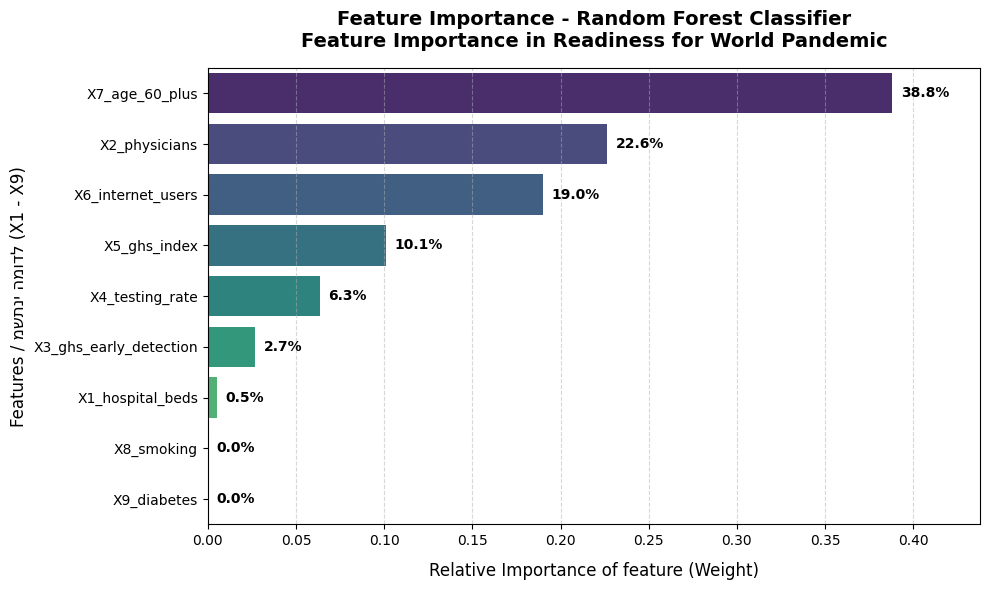


📋 טבלת חשיבות המשתנים המספרית המעודכנת:
X7_age_60_plus: 38.79%
X2_physicians: 22.62%
X6_internet_users: 19.00%
X5_ghs_index: 10.08%
X4_testing_rate: 6.34%
X3_ghs_early_detection: 2.67%
X1_hospital_beds: 0.50%
X8_smoking: 0.00%
X9_diabetes: 0.00%


In [11]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier

# הגדרת נתיב העבודה שלכן (ליזה, רווית, חגית והודיה)
data_dir = '/content/drive/MyDrive/DS_IsTheWorldReadyForTheNextPandemic/DATASET TO USE/'
FILE_NAME = 'master_model_feature_matrix.csv'

# טעינת הנתונים
df_model = pd.read_csv(os.path.join(data_dir, FILE_NAME))

# הפרדת הנתונים ל-X ו-Y
X_raw = df_model.drop(columns=['location_key', 'Y_is_ready'])
y = df_model['Y_is_ready']

# 1. השלמת ערכים חסרים (Imputation) חסינה לשגיאות אורך
# keep_empty_features=True מבטיח שעמודות ריקות לחלוטין לא יימחקו מהמערך!
imputer = SimpleImputer(strategy='median', keep_empty_features=True)
X_imputed_array = imputer.fit_transform(X_raw)

# החזרת המערך ל-DataFrame בצורה בטוחה ותואמת באורכים
X_final = pd.DataFrame(X_imputed_array, columns=X_raw.columns)

# מילוי ערך קבוע בטוח (0) לעמודות שנותרו ריקות כדי שהמודל יוכל לעבד אותן
X_final = X_final.fillna(0)

# 2. אימון מודל היער האקראי הסופי
rf_model = RandomForestClassifier(n_estimators=100, max_depth=4, min_samples_split=5, random_state=42)
rf_model.fit(X_final, y)

# 3. חילוץ חשיבות המשתנים המדויקת
importances = rf_model.feature_importances_
feature_names = X_final.columns

# יצירת DataFrame מסודר לגרף
df_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# =====================================================================
# 4. עיצוב והפקת הגרף (Feature Importance Plot)
# =====================================================================
plt.figure(figsize=(10, 6))

# שימוש בפלטת צבעים אסתטית מבית Seaborn
sns.barplot(
    x='Importance',
    y='Feature',
    data=df_importance,
    palette='viridis',
    hue='Feature',
    legend=False
)

# הוספת כותרות ועיצוב הצירים (מתוקן ללא אזהרות סינטקס)
plt.title('Feature Importance - Random Forest Classifier\nFeature Importance in Readiness for World Pandemic', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Relative Importance of feature (Weight)', fontsize=12, labelpad=10)
plt.ylabel('Features / משתני המודל (X1 - X9)', fontsize=12)

# הוספת ערכים מספריים מדויקים על גבי הברים
for index, value in enumerate(df_importance['Importance']):
    plt.text(value + 0.005, index, f'{value:.1%}', va='center', ha='left', fontsize=10, fontweight='bold')

# הגדרת גבולות הציר בצורה אסתטית
plt.xlim(0, df_importance['Importance'].max() + 0.05)
plt.grid(axis='x', linestyle='--', alpha=0.5)

# הצגת הגרף
plt.tight_layout()
plt.show()

# הדפסת הטבלה המספרית מתחת לגרף
print("\n📋 טבלת חשיבות המשתנים המספרית המעודכנת:")
print("====================================")
for idx, row in df_importance.iterrows():
    print(f"{row['Feature']}: {row['Importance']:.2%}")
print("====================================")


## Confusion Matrix




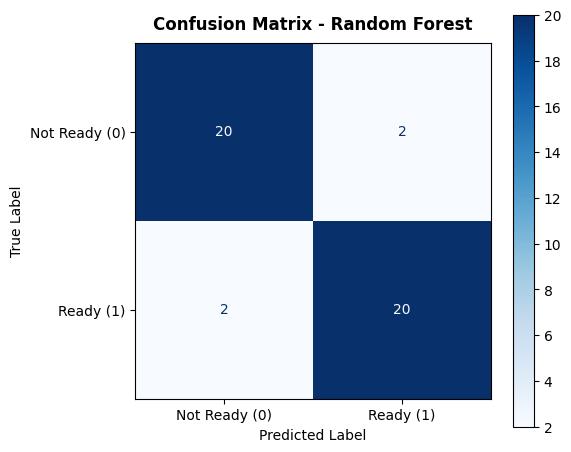

In [16]:
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# טעינה והכנה מהירה
df_model = pd.read_csv(os.path.join(data_dir, 'master_model_feature_matrix.csv'))
X = df_model.drop(columns=['location_key', 'Y_is_ready'])
y = df_model['Y_is_ready']

# חלוקה לייצוג ויזואלי
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# אימון הצינור
pipeline_rf = Pipeline([
    ('imputer', SimpleImputer(strategy='median', keep_empty_features=True)),
    ('classifier', RandomForestClassifier(n_estimators=100, max_depth=4, random_state=42))
])
pipeline_rf.fit(X_train, y_train)
y_pred = pipeline_rf.predict(X_test)

# הפקת המטריצה
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Ready (0)', 'Ready (1)'])

plt.figure(figsize=(6, 5))
disp.plot(cmap='Blues', ax=plt.gca(), values_format='d')
plt.title('Confusion Matrix - Random Forest', fontsize=12, fontweight='bold', pad=10)
plt.xlabel('Predicted Label', fontsize=10)
plt.ylabel('True Label', fontsize=10)
plt.tight_layout()
plt.show()


## Scatter Plot




/usr/local/lib/python3.12/dist-packages/statsmodels/genmod/families/links.py:198: RuntimeWarning: overflow encountered in exp
  t = np.exp(-z)
/usr/local/lib/python3.12/dist-packages/statsmodels/genmod/families/links.py:198: RuntimeWarning: overflow encountered in exp
  t = np.exp(-z)
/usr/local/lib/python3.12/dist-packages/statsmodels/genmod/families/links.py:198: RuntimeWarning: overflow encountered in exp
  t = np.exp(-z)
/usr/local/lib/python3.12/dist-packages/statsmodels/genmod/families/links.py:198: RuntimeWarning: overflow encountered in exp
  t = np.exp(-z)
/usr/local/lib/python3.12/dist-packages/statsmodels/genmod/families/links.py:198: RuntimeWarning: overflow encountered in exp
  t = np.exp(-z)
/usr/local/lib/python3.12/dist-packages/statsmodels/genmod/families/links.py:198: RuntimeWarning: overflow encountered in exp
  t = np.exp(-z)
/usr/local/lib/python3.12/dist-packages/statsmodels/genmod/families/links.py:198: RuntimeWarning: overflow encountered in exp
  t = np.exp(-z)

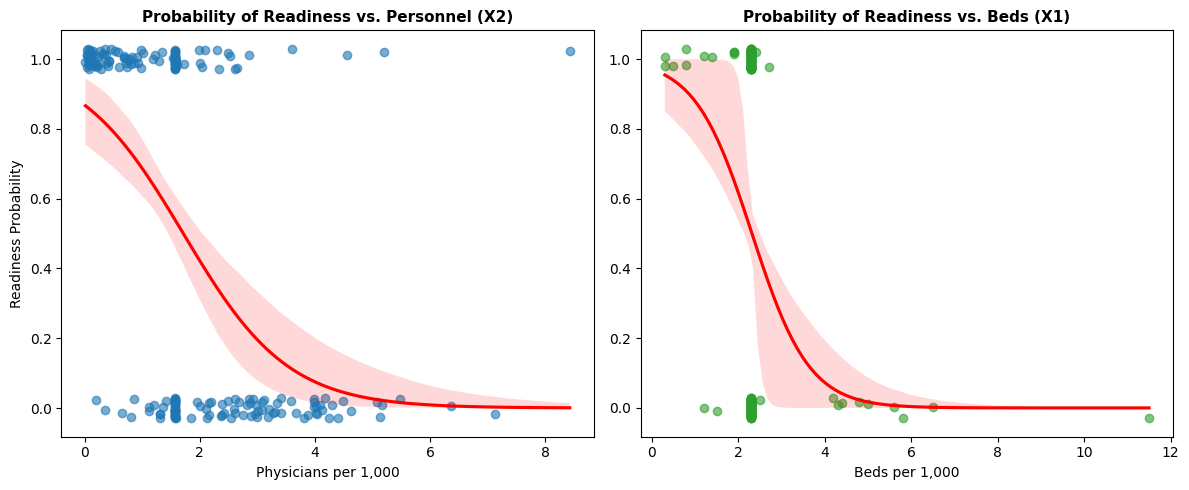

In [17]:
plt.figure(figsize=(12, 5))

# גרף א': קשר בין רופאים (X2) למוכנות
plt.subplot(1, 2, 1)
sns.regplot(x='X2_physicians', y='Y_is_ready', data=df_model, logistic=True,
            y_jitter=0.03, scatter_kws={'alpha':0.6, 'color':'#1f77b4'}, line_kws={'color':'red'})
plt.title('Probability of Readiness vs. Personnel (X2)', fontsize=11, fontweight='bold')
plt.xlabel('Physicians per 1,000')
plt.ylabel('Readiness Probability')

# גרף ב': קשר בין מיטות (X1) למוכנות
plt.subplot(1, 2, 2)
sns.regplot(x='X1_hospital_beds', y='Y_is_ready', data=df_model, logistic=True,
            y_jitter=0.03, scatter_kws={'alpha':0.6, 'color':'#2ca02c'}, line_kws={'color':'red'})
plt.title('Probability of Readiness vs. Beds (X1)', fontsize=11, fontweight='bold')
plt.xlabel('Beds per 1,000')
plt.ylabel('')

plt.tight_layout()
plt.show()


## Violin Plot




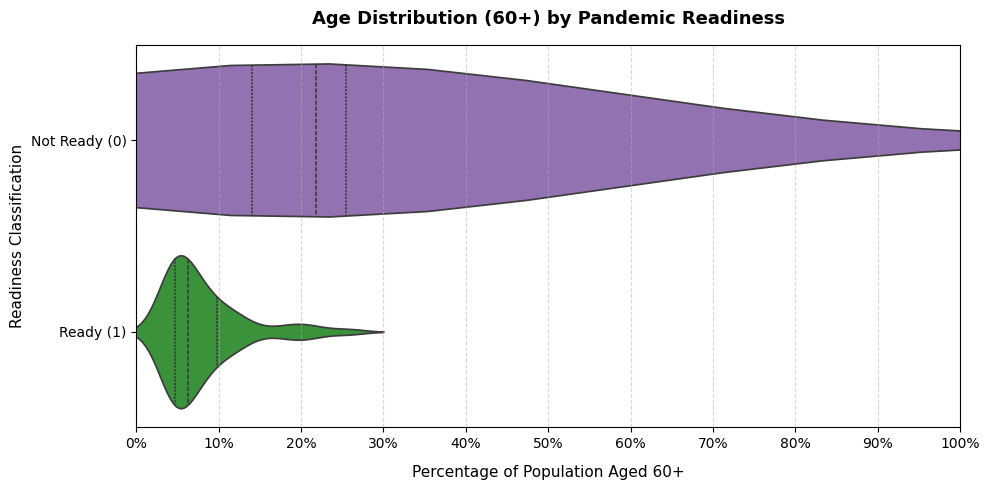

In [22]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# הגדרת נתיב העבודה שלכן (ליזה, רווית, חגית והודיה)
data_dir = '/content/drive/MyDrive/DS_IsTheWorldReadyForTheNextPandemic/DATASET TO USE/'
df_model = pd.read_csv(os.path.join(data_dir, 'master_model_feature_matrix.csv'))

# =====================================================================
# הפקת גרף כינור (Violin Plot) עם סקאלה מורחבת עד 100%
# =====================================================================
plt.figure(figsize=(10, 5))

# יצירת מפות טקסט ברורות לציר ה-X הויזואלי
df_plot = df_model.copy()
df_plot['Readiness_Label'] = df_plot['Y_is_ready'].map({
    1: 'Ready (1)',
    0: 'Not Ready (0)'
})

# ציור גרף הכינור
sns.violinplot(
    x='X7_age_60_plus',
    y='Readiness_Label',
    data=df_plot,
    palette={'Ready (1)': '#2ca02c', 'Not Ready (0)': '#9467bd'},
    hue='Readiness_Label',
    legend=False,
    inner='quartile', # מציג קווי רבעונים (חציון וממוצע) בתוך הכינור
    orient='h'        # גרף אופקי לקריאה נוחה של אחוזים
)

# 🛠️ התיקון הקריטי: קביעת סקאלת אחוזים רחבה מ-0 עד 100
plt.xlim(0, 100)

# הגדרת שנתות (Ticks) בכל 10% כדי להקל על הקריאה
plt.xticks(range(0, 101, 10), [f'{i}%' for i in range(0, 101, 10)])

# הוספת כותרות ועיצוב
plt.title('Age Distribution (60+) by Pandemic Readiness', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Percentage of Population Aged 60+', fontsize=11, labelpad=10)
plt.ylabel('Readiness Classification', fontsize=11)

# הוספת רשת עזר אנכית לסריקה מהירה של האחוזים
plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

